In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import load_gray, remove_background, crop_to_signature

DATA_DIR = Path("../data/signatures")
org_dir = DATA_DIR / "full_org"
forg_dir = DATA_DIR / "full_forg"

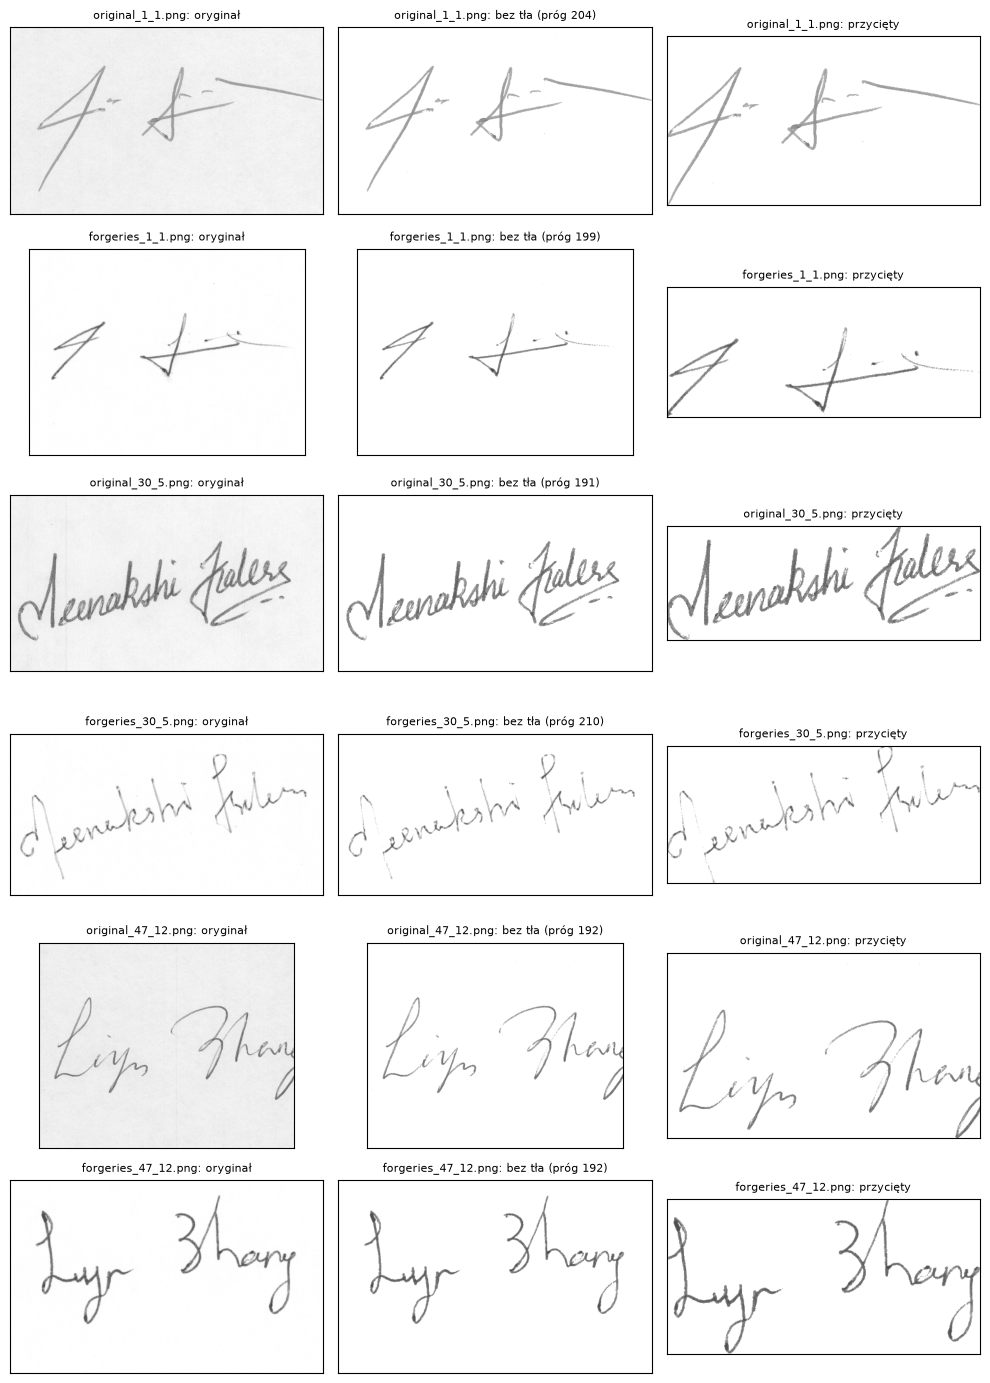

In [2]:
examples = [
    org_dir / "original_1_1.png", forg_dir / "forgeries_1_1.png",
    org_dir / "original_30_5.png", forg_dir / "forgeries_30_5.png",
    org_dir / "original_47_12.png", forg_dir / "forgeries_47_12.png",
]

fig, axes = plt.subplots(len(examples), 3, figsize=(10, 14))
for row, path in enumerate(examples):
    img = load_gray(path)
    clean, threshold = remove_background(img)
    crop = crop_to_signature(clean)
    for col, (image, title) in enumerate([(img, "oryginał"), (clean, f"bez tła (próg {threshold:.0f})"), (crop, "przycięty")]):
        axes[row, col].imshow(image, cmap="gray", vmin=0, vmax=255)
        axes[row, col].set_title(f"{path.name}: {title}", fontsize=8)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
plt.tight_layout()
plt.show()

In [3]:
def analyze_folder(folder):
    thresholds, backgrounds, ink_levels, aspects = [], [], [], []
    for path in sorted(folder.glob("*.png")):
        img = load_gray(path)
        clean, threshold = remove_background(img)
        crop = crop_to_signature(clean)
        thresholds.append(threshold)
        backgrounds.append(np.median(clean))
        ink_levels.append(np.median(clean[clean < 255]))
        aspects.append(crop.shape[1] / crop.shape[0])
    return {
        "próg Otsu": np.array(thresholds),
        "mediana obrazu (tło)": np.array(backgrounds),
        "jasność atramentu": np.array(ink_levels),
        "proporcja szer./wys. po przycięciu": np.array(aspects),
    }

stats_org = analyze_folder(org_dir)
stats_forg = analyze_folder(forg_dir)

for name in stats_org:
    o, f = stats_org[name], stats_forg[name]
    print(f"{name}:")
    print(f"  prawdziwe:   min {o.min():.2f}, mediana {np.median(o):.2f}, max {o.max():.2f}")
    print(f"  fałszerstwa: min {f.min():.2f}, mediana {np.median(f):.2f}, max {f.max():.2f}")

próg Otsu:
  prawdziwe:   min 170.00, mediana 188.00, max 210.00
  fałszerstwa: min 174.00, mediana 200.00, max 226.00
mediana obrazu (tło):
  prawdziwe:   min 255.00, mediana 255.00, max 255.00
  fałszerstwa: min 255.00, mediana 255.00, max 255.00
jasność atramentu:
  prawdziwe:   min 98.00, mediana 136.00, max 180.00
  fałszerstwa: min 86.00, mediana 147.00, max 203.00
proporcja szer./wys. po przycięciu:
  prawdziwe:   min 0.63, mediana 2.07, max 10.57
  fałszerstwa: min 0.75, mediana 2.09, max 8.10


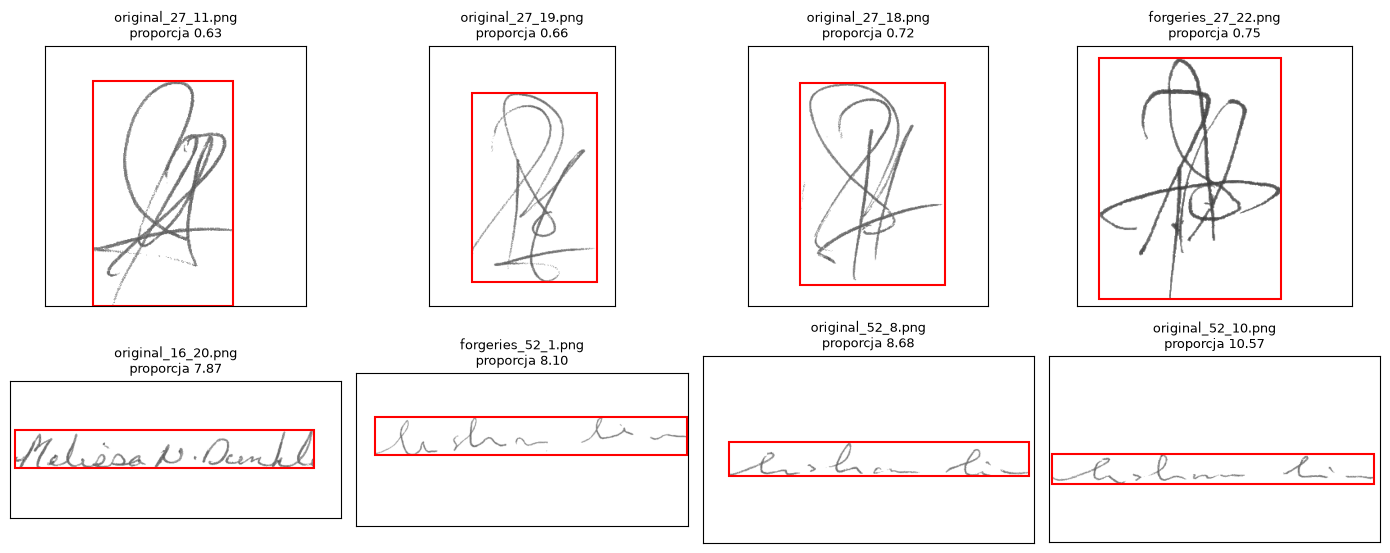

In [4]:
from matplotlib.patches import Rectangle

def crop_aspects(folder):
    result = []
    for path in sorted(folder.glob("*.png")):
        crop = crop_to_signature(remove_background(load_gray(path))[0])
        result.append((crop.shape[1] / crop.shape[0], path))
    return result

aspects_all = sorted(crop_aspects(org_dir) + crop_aspects(forg_dir))
extremes = aspects_all[:4] + aspects_all[-4:]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (aspect, path) in zip(axes.flat, extremes):
    clean = remove_background(load_gray(path))[0]
    mask = clean < 255
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    ax.imshow(clean, cmap="gray", vmin=0, vmax=255)
    ax.add_patch(Rectangle((cols[0], rows[0]), cols[-1] - cols[0], rows[-1] - rows[0],
                           fill=False, edgecolor="red", linewidth=1.5))
    ax.set_title(f"{path.name}\nproporcja {aspect:.2f}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

In [5]:
import csv

ink = {}
for folder in [org_dir, forg_dir]:
    for path in folder.glob("*.png"):
        clean, _ = remove_background(load_gray(path))
        ink[path.name] = np.median(clean[clean < 255])

def pair_ink_diff(csv_name):
    with open(f"../data/{csv_name}") as f:
        rows = list(csv.DictReader(f))
    return np.array([abs(ink[r["file_a"]] - ink[r["file_b"]]) for r in rows])

def eer(pos, neg):
    thresholds = np.sort(np.concatenate([pos, neg]))
    best_diff, best_eer, best_t = None, None, None
    for t in thresholds:
        frr = np.mean(pos < t)
        far = np.mean(neg >= t)
        if best_diff is None or abs(far - frr) < best_diff:
            best_diff, best_eer, best_t = abs(far - frr), (far + frr) / 2, t
    return best_eer, best_t

diff_gen = pair_ink_diff("genuine_pairs.csv")
diff_skilled = pair_ink_diff("skilled_forgery_pairs.csv")

print(f"różnica jasności atramentu w parze, mediana: prawdziwy–prawdziwy {np.median(diff_gen):.1f}, "
      f"prawdziwy–fałszerstwo {np.median(diff_skilled):.1f}")
eer_ink, _ = eer(-diff_gen, -diff_skilled)
print(f"EER, gdyby decydować tylko po jasności atramentu: {eer_ink:.1%}")

różnica jasności atramentu w parze, mediana: prawdziwy–prawdziwy 3.0, prawdziwy–fałszerstwo 18.0
EER, gdyby decydować tylko po jasności atramentu: 21.1%


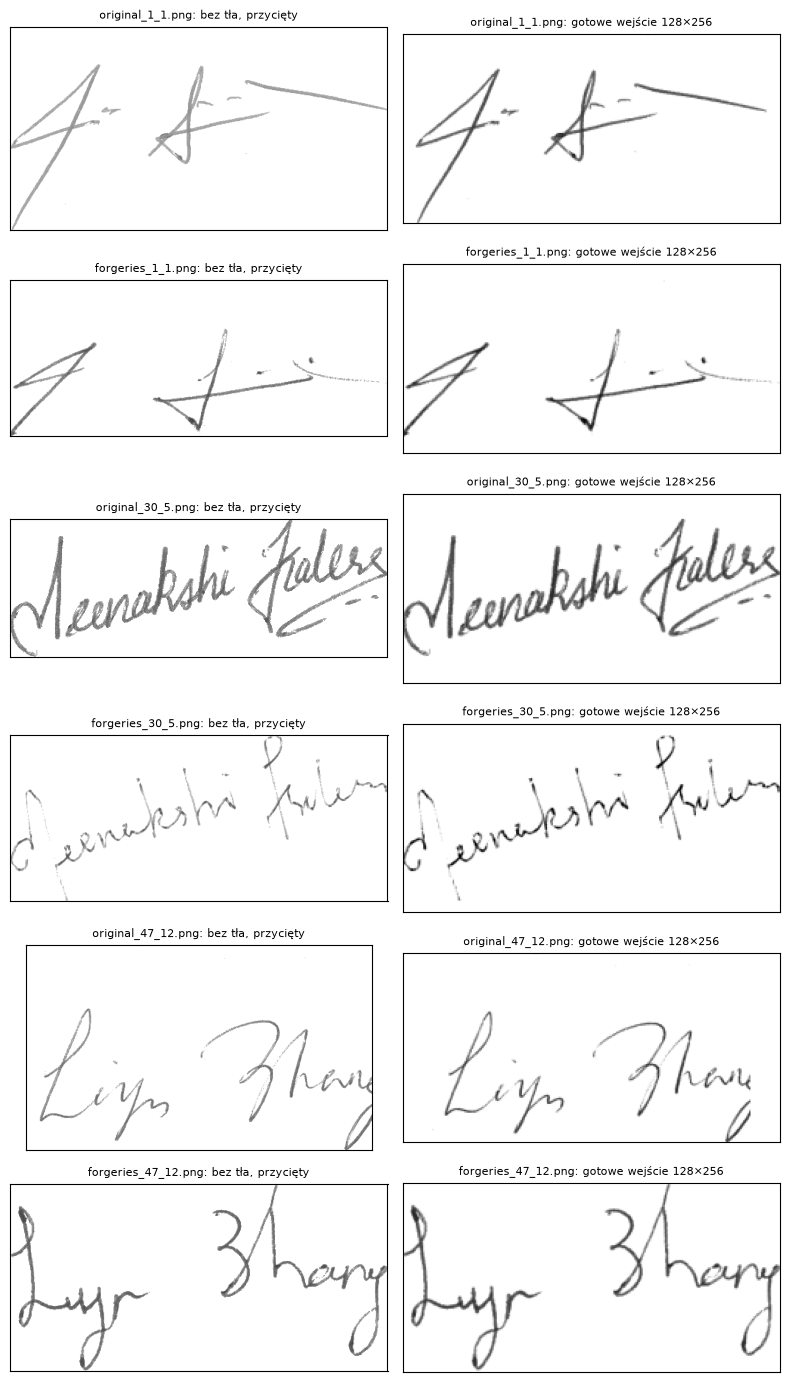

In [6]:
from src.preprocessing import normalize_ink, fit_to_size, preprocess

fig, axes = plt.subplots(len(examples), 2, figsize=(8, 14))
for row, path in enumerate(examples):
    before = crop_to_signature(remove_background(load_gray(path))[0])
    after = preprocess(path)
    for col, (image, title) in enumerate([(before, "bez tła, przycięty"), (after, "gotowe wejście 128×256")]):
        axes[row, col].imshow(image, cmap="gray", vmin=0, vmax=255)
        axes[row, col].set_title(f"{path.name}: {title}", fontsize=8)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
plt.tight_layout()
plt.show()

In [7]:
processed = {}
for folder in [org_dir, forg_dir]:
    for path in folder.glob("*.png"):
        processed[path.name] = preprocess(path)

def read_pairs(csv_name):
    with open(f"../data/{csv_name}") as f:
        return list(csv.DictReader(f))

def ink_level(img):
    return np.median(img[img < 250])

def corr(a, b):
    return np.corrcoef(a.flatten().astype(np.float32), b.flatten().astype(np.float32))[0, 1]

results = {}
for name in ["genuine_pairs.csv", "skilled_forgery_pairs.csv", "random_forgery_pairs.csv"]:
    rows = read_pairs(name)
    ink_diff = np.array([abs(ink_level(processed[r["file_a"]]) - ink_level(processed[r["file_b"]])) for r in rows])
    corrs = np.array([corr(processed[r["file_a"]], processed[r["file_b"]]) for r in rows])
    results[name] = (ink_diff, corrs)

gen_ink, gen_corr = results["genuine_pairs.csv"]
sk_ink, sk_corr = results["skilled_forgery_pairs.csv"]
rnd_ink, rnd_corr = results["random_forgery_pairs.csv"]

print(f"EER po samym atramencie, fałszerstwa wykwalifikowane: {eer(-gen_ink, -sk_ink)[0]:.1%}  (przed: 21,1%)")
print(f"EER korelacji pikseli, fałszerstwa wykwalifikowane:   {eer(gen_corr, sk_corr)[0]:.1%}  (przed: 38,0%)")
print(f"EER korelacji pikseli, różne osoby:                   {eer(gen_corr, rnd_corr)[0]:.1%}  (przed: 32,3%)")

EER po samym atramencie, fałszerstwa wykwalifikowane: 35.9%  (przed: 21,1%)
EER korelacji pikseli, fałszerstwa wykwalifikowane:   42.1%  (przed: 38,0%)
EER korelacji pikseli, różne osoby:                   31.6%  (przed: 32,3%)


In [8]:
from torch.utils.data import DataLoader
from src.dataset import SignaturePairs

for split in ["train", "val", "test"]:
    ds = SignaturePairs(split)
    print(f"{split}: {len(ds)} par, {len(ds.images)} obrazów, par „ta sama osoba”: {sum(p[2] for p in ds.pairs):.0f}")

loader = DataLoader(SignaturePairs("val"), batch_size=32, shuffle=True)
a, b, y = next(iter(loader))
print("kształt paczki:", a.shape, b.shape, y.shape)
print("wartości pikseli od", a.min().item(), "do", a.max().item())
print("pierwsze etykiety:", y[:8])

train: 3360 par, 1390 obrazów, par „ta sama osoba”: 1680
val: 960 par, 402 obrazów, par „ta sama osoba”: 480
test: 960 par, 402 obrazów, par „ta sama osoba”: 480
kształt paczki: torch.Size([32, 1, 128, 256]) torch.Size([32, 1, 128, 256]) torch.Size([32])
wartości pikseli od 0.0 do 0.9176470637321472
pierwsze etykiety: tensor([0., 1., 0., 0., 0., 1., 1., 1.])
